Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help

In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Loading DataFrame
df = pd.read_csv('HeartFailure.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# checking statistical summary of the dataset
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
df.shape

(918, 12)

In [5]:
# Checking for missing values
df.isna().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Dataset has both numerical (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) and categorical (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope) features.


1. Age: age of the patient [years]
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: oldpeak = ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: output class [1: heart disease, 0: Normal]

In [7]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease is the target (binary: 0 = No disease, 1 = Disease).

In [8]:
# Define columns
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

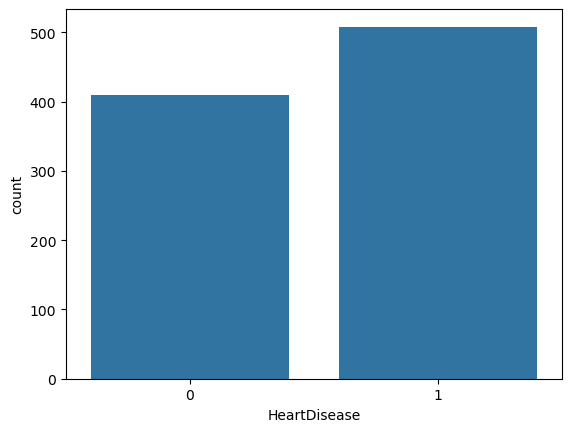

In [9]:
# Visualizing the distribution of the target variable
sns.countplot(x="HeartDisease", data=df)
plt.show()


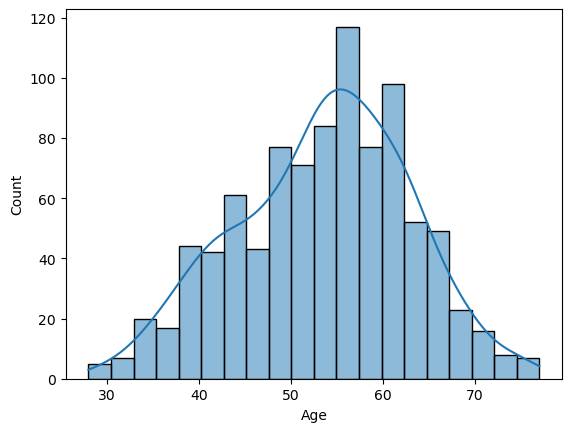

In [10]:
# Visualizing the distribution of the Age variable

sns.histplot(df["Age"], bins=20, kde=True)
plt.show()


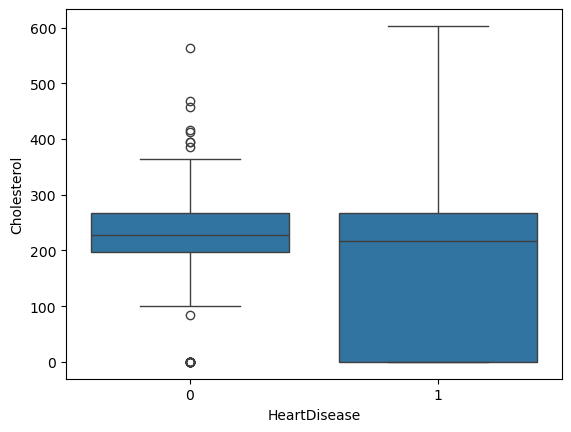

In [11]:
# Visualizing the relationship between Cholesterol and HeartDisease
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)
plt.show()


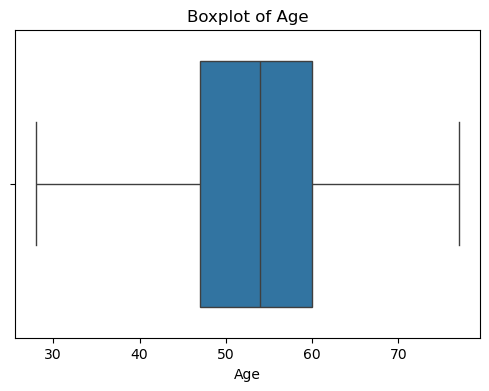

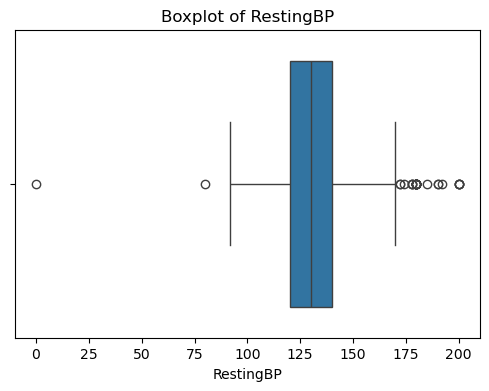

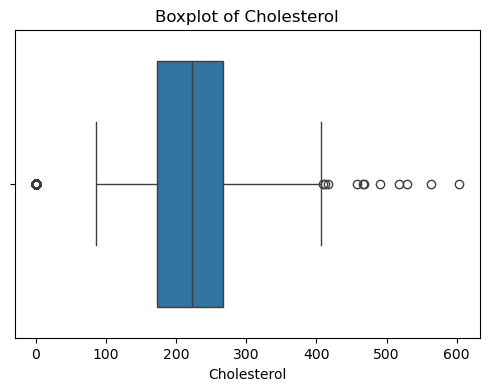

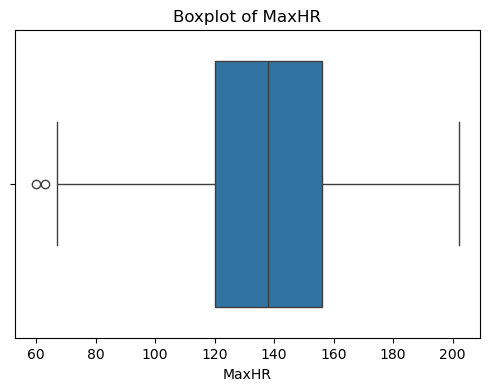

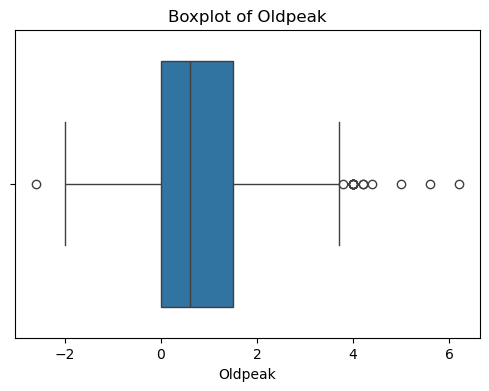

In [12]:
# Boxplots for all numerical features to identify outliers
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [13]:
# Handle outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [14]:
# One-hot encode categorical features
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [15]:
# Scale numerical features
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [16]:
#Train - Test Split
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Preprocessing with ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

In [24]:
# Build  Pipeline with RandomForestClassifier
pipeline = Pipeline(steps=[
    ("classifier", RandomForestClassifier(random_state=42))
])

In [25]:
print(X_train.columns.tolist())


['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [26]:
# Train the model
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))  
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8641304347826086
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



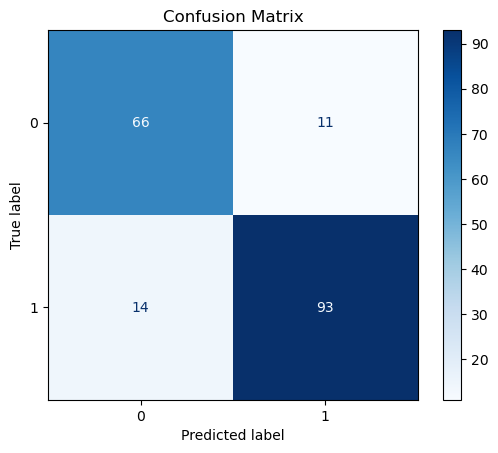

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

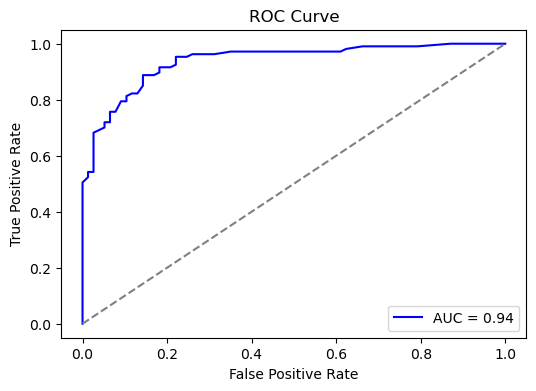

In [28]:
# ROC Curve and AUC
from sklearn.metrics import roc_curve , roc_auc_score
# Probabilities for positive class
y_prob = pipeline.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

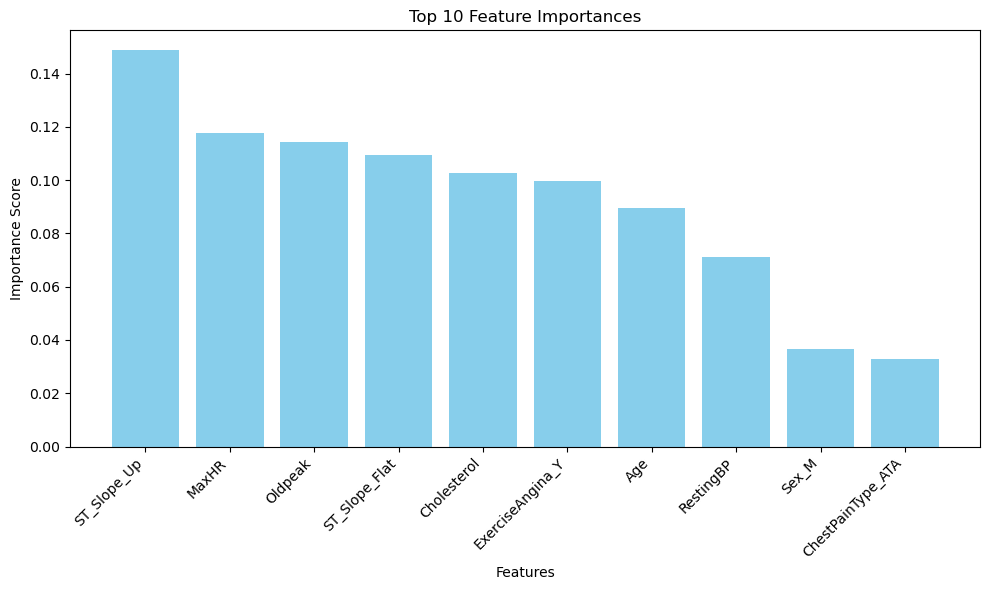

In [29]:
# Feature Importance
# Get feature names from the encoded dataframe
feature_names = X.columns
importances = pipeline.named_steps['classifier'].feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
# plot the top 10 features
plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices[:10]], align="center", color="skyblue")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha="right")
plt.title("Top 10 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


In [34]:
from sklearn.inspection import permutation_importance

result = permutation_importance(pipeline.named_steps["classifier"], X_test, y_test, n_repeats=10, random_state=42)
for i in result.importances_mean.argsort()[::-1][:10]:
    print(X_test.columns[i], result.importances_mean[i])


ST_Slope_Up 0.04891304347826082
Cholesterol 0.027173913043478215
ExerciseAngina_Y 0.01739130434782603
FastingBS 0.010869565217391242
ChestPainType_ATA 0.009782608695652128
RestingBP 0.007608695652173858
Oldpeak 0.007065217391304312
MaxHR 0.004347826086956474
Sex_M 0.0005434782608695343
ChestPainType_NAP -0.002173913043478326


In [35]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=["No Disease","Disease"], discretize_continuous=True)
exp = explainer.explain_instance(X_test.iloc[0].values, pipeline.named_steps["classifier"].predict_proba)
exp.show_in_notebook(show_table=True)



c:\Users\CG\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
import joblib

joblib.dump(pipeline, "heart_disease_pipeline.pkl")
loaded_pipeline = joblib.load("heart_disease_pipeline.pkl")

y_pred = loaded_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8641304347826086
